# Introduction
This notebook is intended to clean the precipitation data of the cities of Seattle, Washington and Hilo, Hawaii.

We are trying to determine which city is "rainier" by looking at which city experiences more days where it actually rains, and which city experiences more precipitation overall.

The original Seattle and Hilo data was sourced from NOAA:

https://www.ncei.noaa.gov/cdo-web/search?datasetid=GHCND

This notebook will output a cleaned csv in tidy format which will then be analyzed in a seperate notebook. The dataset will be output into the data folder

# Load and explore the data

## Import libraries

In [1]:
# Import pandas, numpy, matplotlib and seaborns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# set the plotting style
sns.set_style("whitegrid")

## Load the data

##### Load the Seattle data set from the Github repo/ data folder

In [2]:
df_seattle= pd.read_csv(
    'https://raw.githubusercontent.com/ayoung42/5100-weather-project/refs/heads/main/data/seattle_rain.csv'
)

##### Load the Hilo data set from the Github repo/ data folder

In [3]:
df_hilo= pd.read_csv(
    'https://raw.githubusercontent.com/ayoung42/5100-weather-project/refs/heads/main/data/hilo_rain.csv'
)

## Explore the contents of the data sets

In [4]:
df_seattle.head()

,STATION,NAME,DATE,DAPR,MDPR,PRCP,SNOW,SNWD,WESD,WESF
0,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/1/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
1,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/2/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
2,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/3/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
3,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/4/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
4,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/5/18,NaN,NaN,0.25,NaN,NaN,NaN,NaN


In [5]:
df_hilo.head()

,STATION,NAME,DATE,PRCP
0,USW00021504,"HILO INTERNATIONAL AIRPORT 87, HI US",2018-01-01,0.00
1,USW00021504,"HILO INTERNATIONAL AIRPORT 87, HI US",2018-01-02,0.00
2,USW00021504,"HILO INTERNATIONAL AIRPORT 87, HI US",2018-01-03,0.01
3,USW00021504,"HILO INTERNATIONAL AIRPORT 87, HI US",2018-01-04,0.00
4,USW00021504,"HILO INTERNATIONAL AIRPORT 87, HI US",2018-01-05,0.00


#### Use different methods to examine the dataframes
We can see that the columns are not the same, there are missing values, and there are a different amount of observations in both datasets

In [6]:
df_seattle.columns

Index(['STATION', 'NAME', 'DATE', 'DAPR', 'MDPR', 'PRCP', 'SNOW', 'SNWD',
       'WESD', 'WESF'],
      dtype='object')

In [7]:
df_hilo.columns

Index(['STATION', 'NAME', 'DATE', 'PRCP'], dtype='object')

##### Use the `info` method to check the data types, size of the data frame, and numbers of missing values.

In [8]:
df_seattle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1658 entries, 0 to 1657
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1658 non-null   object 
 1   NAME     1658 non-null   object 
 2   DATE     1658 non-null   object 
 3   DAPR     23 non-null     float64
 4   MDPR     23 non-null     float64
 5   PRCP     1636 non-null   float64
 6   SNOW     353 non-null    float64
 7   SNWD     66 non-null     float64
 8   WESD     15 non-null     float64
 9   WESF     28 non-null     float64
dtypes: float64(7), object(3)
memory usage: 129.7+ KB


##### Hilo data set

In [9]:
df_hilo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1826 non-null   object 
 1   NAME     1826 non-null   object 
 2   DATE     1826 non-null   object 
 3   PRCP     1826 non-null   float64
dtypes: float64(1), object(3)
memory usage: 57.2+ KB


##### We can also compare data frame sizes using the shape attribute

In [10]:
df_seattle.shape

(1658, 10)

In [11]:
df_hilo.shape

(1826, 4)

### Why might the Hilo data set be larger?

##### The Hilo dataset seems to have the expected amount of entries (365*5+1)= 1826, whereas the Seattle dataset seems to be missing entries with only 1658 of the expected 1826 present.

#### Examine the `STATION` column

##### The Hilo data set and Seattle datasets both only have one station.

However, we will ensure that the data we use for Hilo is from the airport, and Seattle data is using the monitor closest to SU, which is Seattle 2.1

In [12]:
df_seattle= df_seattle.loc[df_seattle['NAME']== 'SEATTLE 2.1 ESE, WA US']

In [13]:
df_hilo= df_hilo.loc[df_hilo['NAME']== 'HILO INTERNATIONAL AIRPORT 87, HI US']

In [14]:
df_seattle['STATION'].unique()

array(['US1WAKG0225'], dtype=object)

In [15]:
df_hilo['STATION'].unique()

array(['USW00021504'], dtype=object)

### Convert `DATE` to datetime

In [16]:
df_seattle['DATE'] = pd.to_datetime(df_seattle['DATE'])
df_seattle['DATE'].tail()
df_hilo['DATE'] = pd.to_datetime(df_hilo['DATE'])

C:\Users\ahria\AppData\Local\Temp\ipykernel_17564\1422924926.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_seattle['DATE'] = pd.to_datetime(df_seattle['DATE'])


#### Now that the dates are standardized, we can verify that each dataset is within the range of dates we had determined (Jan 1, 2018- Dec 31, 2022)

In [17]:
df_seattle['DATE'].agg(['min','max'])

min   2018-01-01
max   2022-12-31
Name: DATE, dtype: datetime64[ns]

In [18]:
df_hilo['DATE'].agg(['min', 'max'])

min   2018-01-01
max   2022-12-31
Name: DATE, dtype: datetime64[ns]

### Plot the daily precipitation data for Seattle.

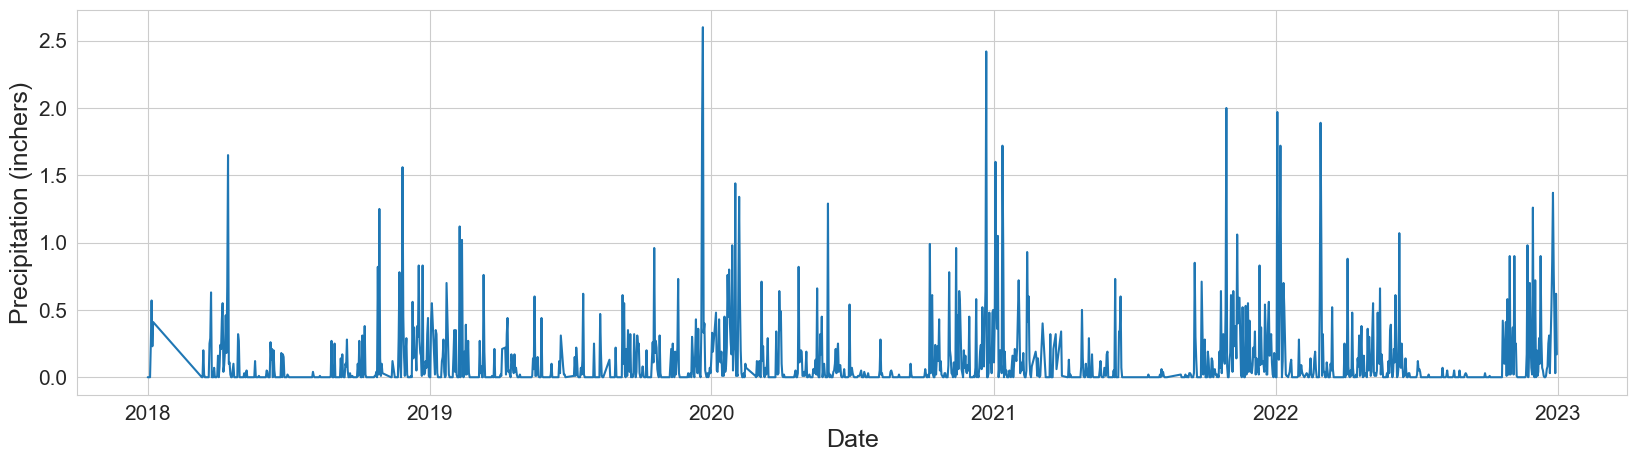

In [19]:
plt.figure(figsize= (20,5))

sns.lineplot(data= df_seattle, x = 'DATE', y = 'PRCP')

plt.xlabel('Date', fontsize= 18)
plt.ylabel('Precipitation (inchers)', fontsize = 18)

plt.tick_params(labelsize = 15)
plt.show()

##### We can see a diagonal line in the data from early 2018 to 1/3 of the way into 2018 which indicates missing data. Since this is a line plot we expect to see thin lines in a row next to each other. Any connective lines like this are cause to examine the data

##### Plot the daily precipitation data for Hilo.

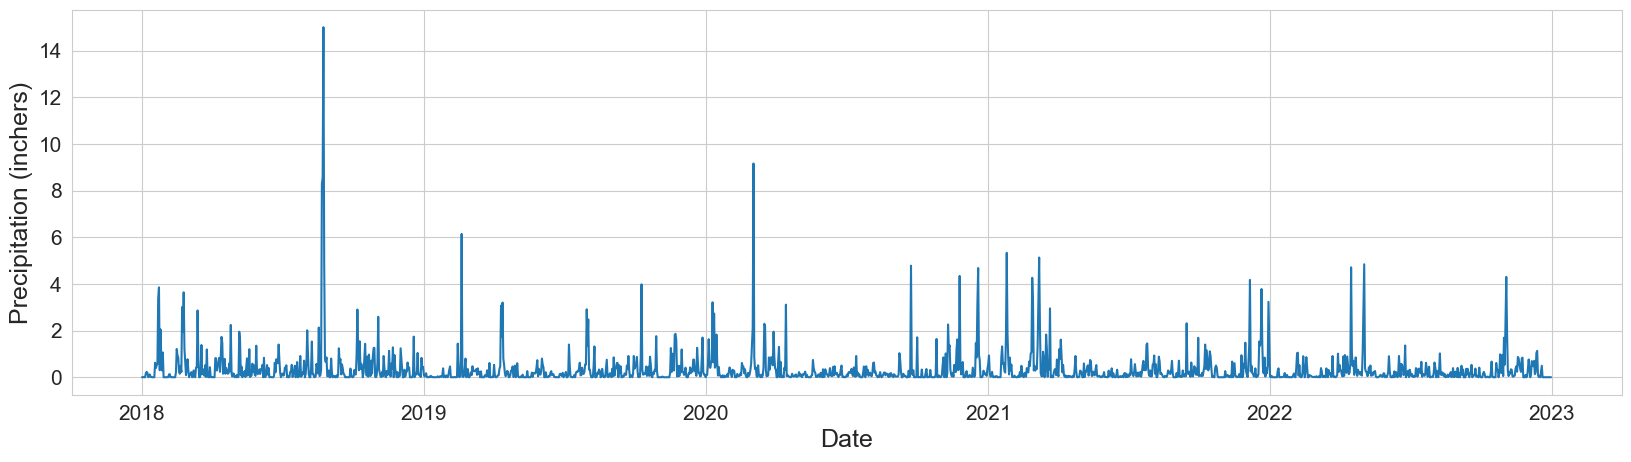

In [20]:
plt.figure(figsize= (20,5))

sns.lineplot(data= df_hilo, x = 'DATE', y = 'PRCP')

plt.xlabel('Date', fontsize= 18)
plt.ylabel('Precipitation (inchers)', fontsize = 18)

plt.tick_params(labelsize = 15)
plt.show()

### Select multiple columns

Select the columns containing `STATION`, `DATE`, and precipitation `PRCP`.

In [21]:
df_seattle[["STATION", "DATE", "PRCP"]]
df_hilo[["STATION", "DATE", "PRCP"]]

,STATION,DATE,PRCP
0,USW00021504,2018-01-01,0.00
1,USW00021504,2018-01-02,0.00
2,USW00021504,2018-01-03,0.01
3,USW00021504,2018-01-04,0.00
4,USW00021504,2018-01-05,0.00
...,...,...,...
1821,USW00021504,2022-12-27,0.00
1822,USW00021504,2022-12-28,0.00
1823,USW00021504,2022-12-29,0.00
1824,USW00021504,2022-12-30,0.00


## Select relevant subsets of the data

Make sure that the datasets do not contain data prior to 2018.

In [22]:
df_hilo= df_hilo.loc[df_hilo['DATE'] >= '2018-01-01']

In [23]:
df_seattle = df_seattle.loc[df_seattle['DATE'] >= '2018-01-01']

In [24]:
df_hilo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1826 entries, 0 to 1825
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   STATION  1826 non-null   object        
 1   NAME     1826 non-null   object        
 2   DATE     1826 non-null   datetime64[ns]
 3   PRCP     1826 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 71.3+ KB


In [25]:
df_seattle.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1658 entries, 0 to 1657
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   STATION  1658 non-null   object        
 1   NAME     1658 non-null   object        
 2   DATE     1658 non-null   datetime64[ns]
 3   DAPR     23 non-null     float64       
 4   MDPR     23 non-null     float64       
 5   PRCP     1636 non-null   float64       
 6   SNOW     353 non-null    float64       
 7   SNWD     66 non-null     float64       
 8   WESD     15 non-null     float64       
 9   WESF     28 non-null     float64       
dtypes: datetime64[ns](1), float64(7), object(2)
memory usage: 142.5+ KB


## Join data frames keeping `DATE` and `PRCP` columns

**What type of join should we do?**

##### Outer join, since it keeps the data where they are not the same

In [26]:
df= df_hilo[['DATE','PRCP']].merge(df_seattle[['DATE','PRCP']], on= 'DATE', how ='outer')

In [27]:
df

,DATE,PRCP_x,PRCP_y
0,2018-01-01,0.00,0.00
1,2018-01-02,0.00,0.00
2,2018-01-03,0.01,0.00
3,2018-01-04,0.00,0.00
4,2018-01-05,0.00,0.25
...,...,...,...
1821,2022-12-27,0.00,0.78
1822,2022-12-28,0.00,0.40
1823,2022-12-29,0.00,0.03
1824,2022-12-30,0.00,0.62


In [28]:
df.shape

(1826, 3)

### Create a tidy data frame with columns for city and precipitation

How did this change the DataFrame?

In [29]:
df= pd.melt(df, id_vars=['DATE'], var_name='city', value_name='precipitation')
df.head()

,DATE,city,precipitation
0,2018-01-01,PRCP_x,0.00
1,2018-01-02,PRCP_x,0.00
2,2018-01-03,PRCP_x,0.01
3,2018-01-04,PRCP_x,0.00
4,2018-01-05,PRCP_x,0.00


### Rename columns or values to follow best practices

Rename the city values 'HILO' and 'SEA'

In [30]:
df.loc[df['city'] == 'PRCP_x', 'city'] = 'HILO'
df.loc[df['city'] == 'PRCP_y', 'city'] = 'SEA'

In [31]:
df.head()

,DATE,city,precipitation
0,2018-01-01,HILO,0.00
1,2018-01-02,HILO,0.00
2,2018-01-03,HILO,0.01
3,2018-01-04,HILO,0.00
4,2018-01-05,HILO,0.00


##### Rename the columns to be lowercase using `df.rename()`

In [32]:
df = df.rename(columns={'DATE': 'date'})

In [33]:
df.rename(str.lower, axis='columns')

,date,city,precipitation
0,2018-01-01,HILO,0.00
1,2018-01-02,HILO,0.00
2,2018-01-03,HILO,0.01
3,2018-01-04,HILO,0.00
4,2018-01-05,HILO,0.00
...,...,...,...
3647,2022-12-27,SEA,0.78
3648,2022-12-28,SEA,0.40
3649,2022-12-29,SEA,0.03
3650,2022-12-30,SEA,0.62


## Identify and fill in missing values

Data can be missing in multiple manners:
1. Values are `NaN` in the data frame

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           3652 non-null   datetime64[ns]
 1   city           3652 non-null   object        
 2   precipitation  3462 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 85.7+ KB


2.  Values are not included in the data set.

### Count the non-null or null values

Determine the number of non-null values in each column.

In [35]:
df.notna().sum()

date             3652
city             3652
precipitation    3462
dtype: int64

##### Determine the number of null values in each column.

In [36]:
df.isna().sum()

date               0
city               0
precipitation    190
dtype: int64

##### Determine the number of null precipitation values for Seattle and Hilo.

In [37]:
df.loc[df['city']== 'SEA', 'precipitation'].isna().sum()

np.int64(190)

In [38]:
df.loc[df['city']== 'HILO', 'precipitation'].isna().sum()

np.int64(0)

### Impute missing values

##### Take the average on similar days and replace them

In [39]:
df.isna().sum()

date               0
city               0
precipitation    190
dtype: int64

In [40]:
df.loc[df['city']== 'SEA', 'precipitation'].isna().sum()

np.int64(190)

In [41]:
df.loc[df['city']== 'HILO', 'precipitation'].isna().sum()

np.int64(0)

In [42]:
df['day_of_year']= pd.DatetimeIndex(df['date']).day_of_year

In [43]:
df.head()

,date,city,precipitation,day_of_year
0,2018-01-01,HILO,0.00,1
1,2018-01-02,HILO,0.00,2
2,2018-01-03,HILO,0.01,3
3,2018-01-04,HILO,0.00,4
4,2018-01-05,HILO,0.00,5


In [44]:
mean_day_precipitation = df.loc[
    df['city'] == 'SEA',
    ['precipitation','day_of_year']
].groupby(
    'day_of_year'
).mean()

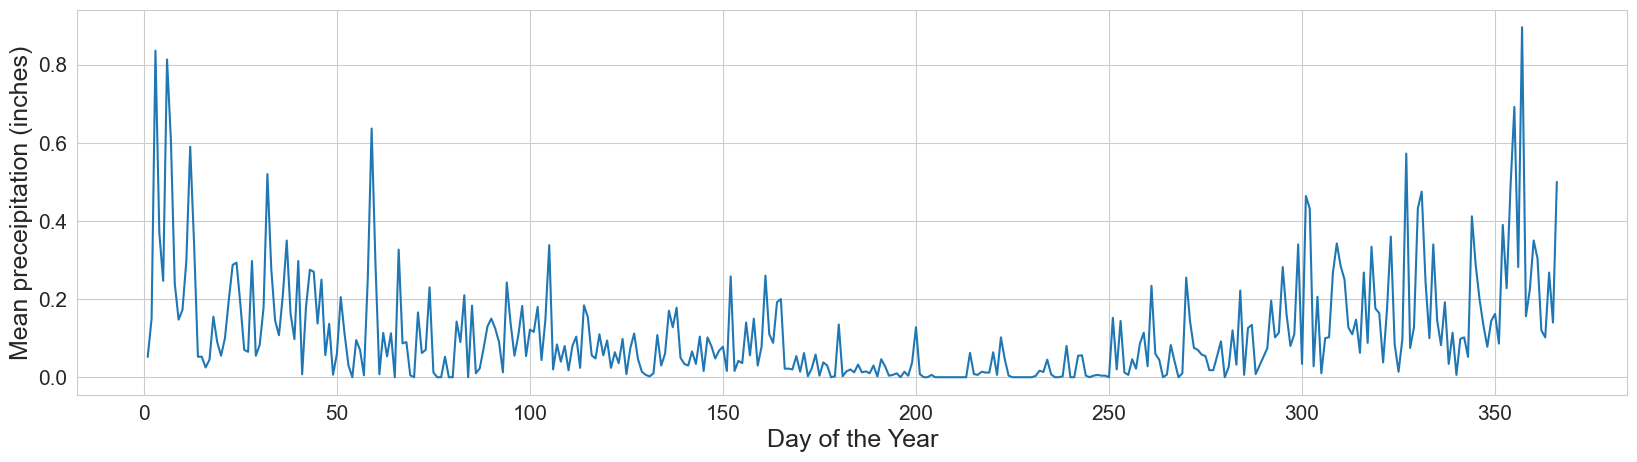

In [45]:
plt.figure(figsize = (20,5))

sns.lineplot(data=mean_day_precipitation, x = 'day_of_year', y = 'precipitation')

plt.xlabel('Day of the Year', fontsize=18)
plt.ylabel('Mean preceipitation (inches)', fontsize = 18)

plt.tick_params(labelsize = 15)
plt.show()

In [46]:
df.head()

,date,city,precipitation,day_of_year
0,2018-01-01,HILO,0.00,1
1,2018-01-02,HILO,0.00,2
2,2018-01-03,HILO,0.01,3
3,2018-01-04,HILO,0.00,4
4,2018-01-05,HILO,0.00,5


In [47]:
df['precipitation'].isna()==True

0       False
1       False
2       False
3       False
4       False
        ...  
3647    False
3648    False
3649    False
3650    False
3651    False
Name: precipitation, Length: 3652, dtype: bool

In [48]:
indices = np.where(df['precipitation'].isna() == True)[0]
indices

array([1834, 1835, 1836, 1837, 1838, 1839, 1840, 1841, 1842, 1843, 1844,
       1845, 1846, 1847, 1848, 1849, 1850, 1851, 1852, 1853, 1854, 1855,
       1856, 1857, 1858, 1859, 1860, 1861, 1862, 1863, 1864, 1865, 1866,
       1867, 1868, 1869, 1870, 1871, 1872, 1873, 1874, 1875, 1876, 1877,
       1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885, 1886, 1887, 1888,
       1889, 1890, 1891, 1892, 1893, 1894, 1895, 2090, 2131, 2132, 2133,
       2134, 2135, 2136, 2137, 2138, 2139, 2140, 2195, 2196, 2197, 2214,
       2215, 2244, 2245, 2246, 2247, 2248, 2249, 2286, 2287, 2288, 2362,
       2363, 2368, 2369, 2370, 2371, 2372, 2373, 2374, 2375, 2376, 2377,
       2417, 2418, 2419, 2420, 2421, 2422, 2423, 2517, 2518, 2519, 2520,
       2521, 2522, 2523, 2524, 2559, 2560, 2561, 2602, 2603, 2604, 2605,
       2606, 2607, 2608, 2609, 2610, 2611, 2612, 2818, 2819, 2820, 2821,
       2822, 2823, 2824, 2825, 2826, 2827, 2972, 2973, 2974, 2975, 2983,
       2984, 2986, 2987, 2988, 3000, 3001, 3004, 30

In [49]:
for index in indices:
    df.loc[index, 'precipitation']= mean_day_precipitation.loc[df.loc[index, 'day_of_year']].values[0]

In [50]:
df.isna().sum()

date             0
city             0
precipitation    0
day_of_year      0
dtype: int64

## Export the clean .csv file

In [53]:
#Exports a clean version of the dataset in tidy format to be used by other people
df.to_csv(
    'https://raw.githubusercontent.com/ayoung42/5100-weather-project/refs/heads/main/data/clean_seattle_hilo_weather.csv', 
    encoding='utf-8-sig', index=False)